# SWIGGY SALES ANALYSIS

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_excel(r"C:\Users\91939\Downloads\swiggy_data.xlsx")

In [5]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


## MetaData

In [8]:
print("Number of rows:",df.shape[0])

Number of rows: 197430


In [9]:
print("Number of columns:",df.shape[1])

Number of columns: 10


In [10]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

## Datatypes

In [12]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

df.describe()

## KPI's

### Total Sales

In [17]:
total_sales = df["Price (INR)"].sum()
print("Total sales (INR):", round(total_sales,2))

Total sales (INR): 53012505.77


### Average Rating 

In [19]:
avg_rating = df["Rating"].mean()
print("Average Rating:", round(avg_rating,2))

Average Rating: 4.34


### Average Order Value

In [20]:
avg_order_value = df["Price (INR)"].mean()
print("Average Order Value (INR):", round(avg_order_value,2))

Average Order Value (INR): 268.51


### Rating Count

In [24]:
rating_count = df["Rating Count"].sum()
print("Rating count:", round(rating_count,2))

Rating count: 5591574


### Total Orders

In [26]:
total_order = df["Order Date"].count()
print("Total orders:", round(total_order,2))

Total orders: 197430


In [27]:
total_order = len(df)
print("Total orders:", round(total_order,2))

Total orders: 197430


# Charts

### Monthly Sales Trend

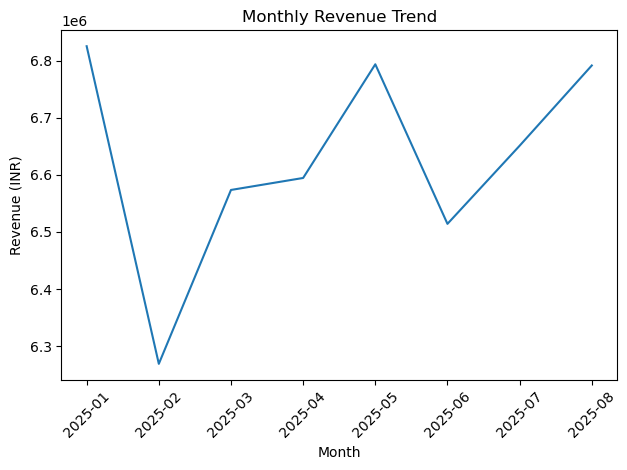

In [29]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Price (INR)"]) #line chart
plt.xticks(rotation = 45) #proper fix of the chart 
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()  #prevent overlap 
plt.show()

### Daily Sales Trend

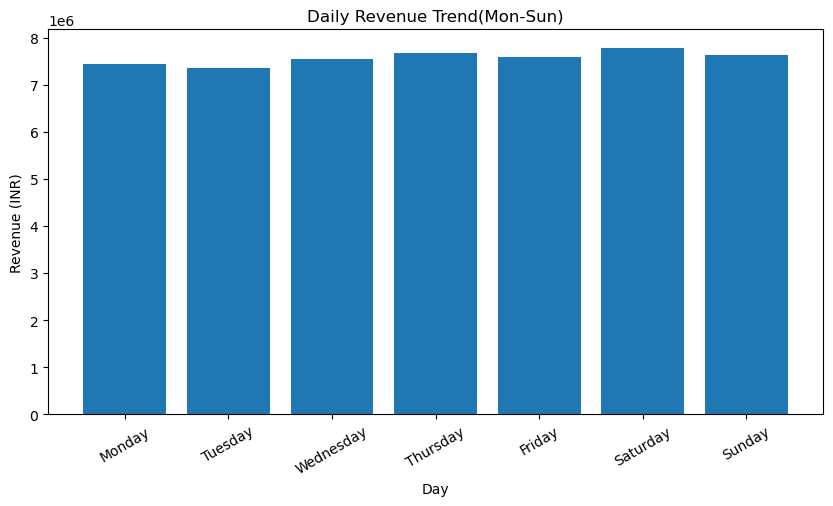

In [33]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_revenue = (
    df.groupby("DayName")["Price (INR)"].sum().
        reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
)

plt.figure(figsize =(10,5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.title("Daily Revenue Trend(Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation = 30)

plt.show()

### Total Sales by Food Type (Veg/Non-Veg)

In [36]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn","biryani","kabab","kebab",
    "non-veg","non veg"
]

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na = False),
    "Non-Veg",
    "Veg"
)


In [37]:
food_revenue = (
    df.groupby("Food Category")["Price (INR)"].sum().reset_index()
)

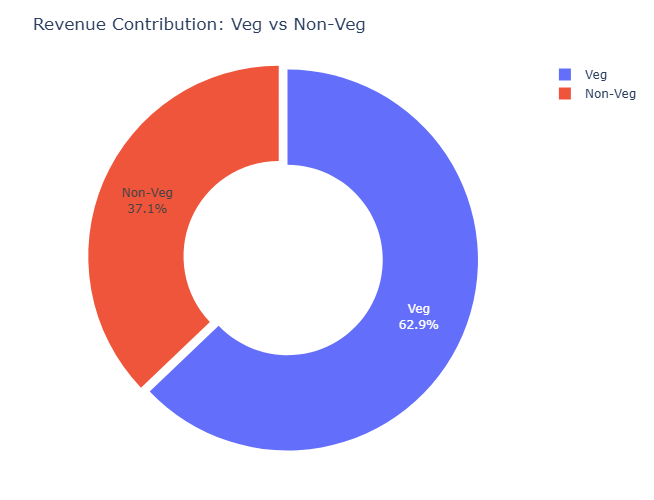

In [39]:
fig = px.pie(
    food_revenue,
    values = "Price (INR)",
    names = "Food Category",
    hole = 0.5,
    title = "Revenue Contribution: Veg vs Non-Veg",
)

fig.update_traces(
    textinfo = "percent+label",
    pull=[0.05,0]
)

fig.update_layout(
    height = 500,
    margin = dict(t=60, b=40, l=40, r=40)
)

fig.show()

### Total sales by state

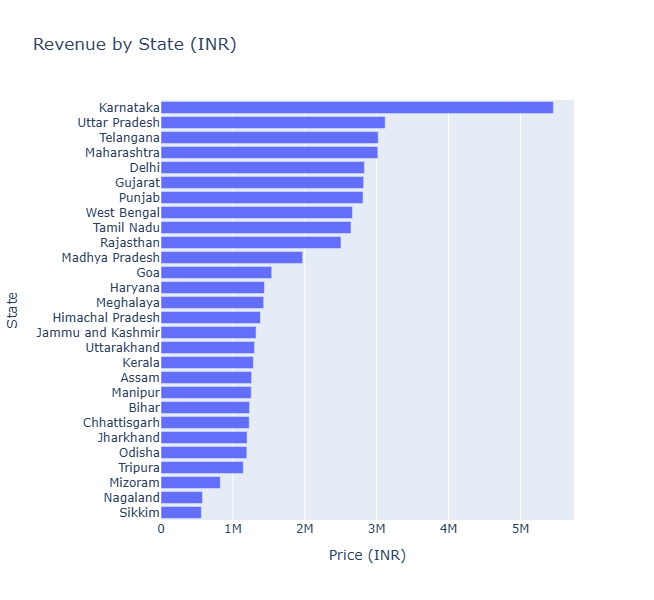

In [40]:
fig = px.bar(
    df.groupby("State", as_index = False)["Price (INR)"].sum().
        sort_values("Price (INR)", ascending = False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State (INR)"
)
fig.update_layout(height = 600, yaxis=dict(autorange="reversed"))
fig.show()

### Quarterly Performance Summary

In [41]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)

quarterly_summary = (
    df.groupby("Quarter", as_index = False).agg(
        total_sales = ("Price (INR)", "sum"),
        avg_rating = ("Rating", "mean"),
        total_orders = ("Order_Date", "count")
    ).sort_values("Quarter")
)

quarterly_summary["total_sales"] = quarterly_summary["total_sales"].round(0)
quarterly_summary["avg_rating"] = quarterly_summary["avg_rating"].round(2)

quarterly_summary

,Quarter,total_sales,avg_rating,total_orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


### Top 5 Cities by Sales

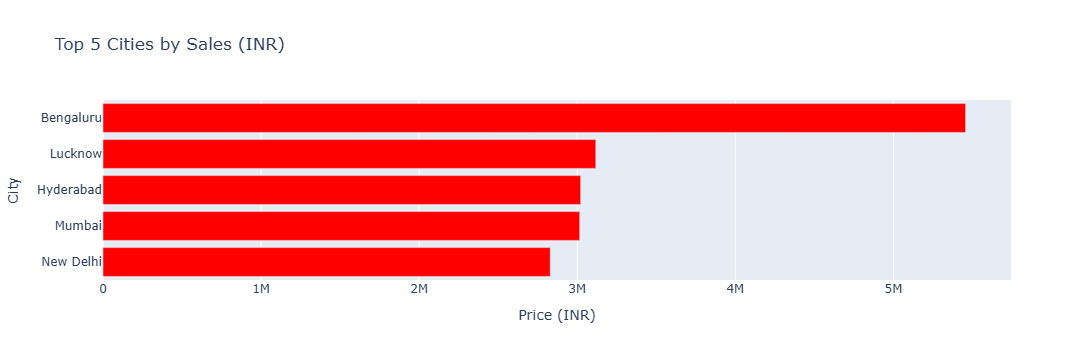

In [43]:
top_5_cities = (
    df.groupby("City")["Price (INR)"].sum()
    .nlargest(5).sort_values().reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation = "h",
    title = "Top 5 Cities by Sales (INR)",
    color_discrete_sequence = ["red"]
)

fig.show()

### Weekly Trend Analysis

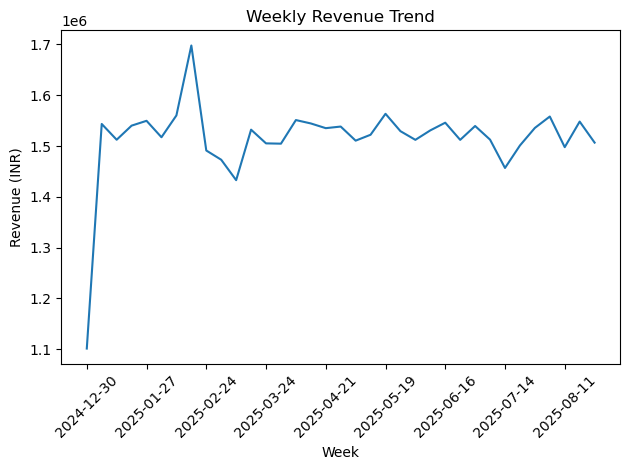

In [45]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Week"] = df["Order Date"].dt.to_period("W").apply(lambda r: r.start_time)
weekly_revenue = df.groupby("Week")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(weekly_revenue["Week"], weekly_revenue["Price (INR)"]) #line chart
plt.xticks(weekly_revenue["Week"][::4], rotation=45)
plt.xlabel("Week")
plt.ylabel("Revenue (INR)")
plt.title("Weekly Revenue Trend")
plt.tight_layout()  #prevent overlap 
plt.show()

### using plotly express

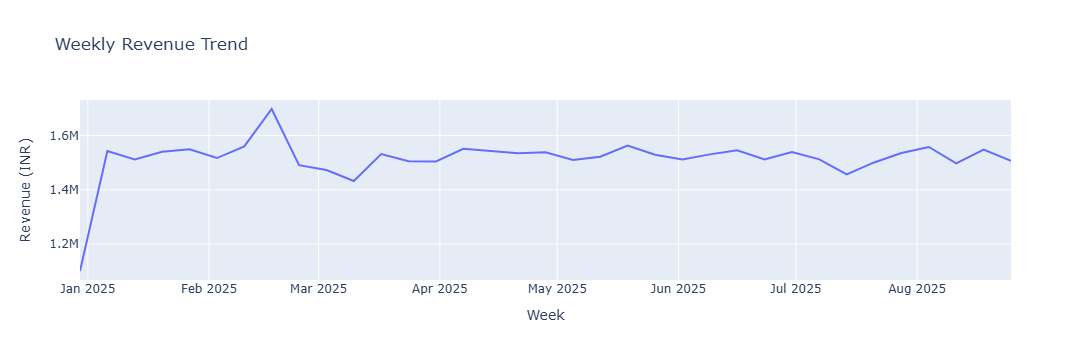

In [47]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Week"] = df["Order Date"].dt.to_period("W").apply(lambda r: r.start_time)
weekly_revenue = df.groupby("Week")["Price (INR)"].sum().reset_index()

fig = px.line(
    weekly_revenue,
    x="Week",
    y="Price (INR)",
    title="Weekly Revenue Trend"
)
fig.update_layout(
    xaxis_title="Week",
    yaxis_title="Revenue (INR)"
)


fig.show()